# 04 · Hình và bảng cho báo cáo

Gom mọi thứ đã chạy thành sản phẩm nộp. Không huấn luyện gì thêm ở đây.

Người phụ trách: **SV B**.

In [1]:
# Chạy được cả trên Colab lẫn máy cá nhân
import sys, os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not Path("unet-kvasir").exists():
    # !git clone <repo cua nhom> unet-kvasir
    pass
ROOT = Path("unet-kvasir") if Path("unet-kvasir").exists() else Path("..")
os.chdir(ROOT.resolve())
sys.path.insert(0, str(Path.cwd()))

%load_ext autoreload
%autoreload 2

from src import *
print("Thư mục làm việc:", Path.cwd())
print("Thiết bị:", get_device())

Thư mục làm việc: /root/workspace/unet-kvasir
Thiết bị: cuda


In [2]:
import pandas as pd

cfg = Config()
df = RunLogger(cfg.log_csv).to_dataframe()
for c in [c for c in df.columns if c.startswith(("test_", "best_val", "n_params",
                                                 "train_time", "focal_", "tversky_"))]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
for c in ("epochs", "seed", "best_epoch", "epochs_run", "batch_size", "image_size"):
    df[c] = df[c].astype(int)
df["lr"] = df["lr"].astype(float)

print(f"Tổng số lượt chạy trong log: {len(df)}")
print(df.groupby("epochs").size().to_string())

Tổng số lượt chạy trong log: 25
epochs
40      6
120    19


## Khử trùng lặp log trước khi lập bảng

Nếu cùng một `run_id` xuất hiện nhiều dòng, chúng dùng chung một đường dẫn
checkpoint — lượt sau đã ghi đè lượt trước, nên chỉ dòng mới nhất còn khớp với
file trên đĩa. `merge_logs` giữ dòng mới nhất.

In [3]:
dups = df[df.duplicated("run_id", keep=False)]
if len(dups):
    print(f"{dups.run_id.nunique()} run_id bị trùng, {len(dups)} dòng:")
    print(dups[["datetime", "run_id", "num_workers", "test_dice"]]
          .sort_values(["run_id", "datetime"]).to_markdown(index=False))
    print("\nChạy ô dưới để khử trùng, rồi nạp lại df.")
else:
    print("Không có run_id trùng.")

2 run_id bị trùng, 4 dòng:
| datetime            | run_id                               |   num_workers |   test_dice |
|:--------------------|:-------------------------------------|--------------:|------------:|
| 2026-08-23T16:31:54 | bce_dice-transpose-full-s1337-4ba512 |             2 |     0.84137 |
| 2026-08-23T18:25:45 | bce_dice-transpose-full-s1337-4ba512 |             8 |     0.84441 |
| 2026-08-23T10:02:07 | bce_dice-transpose-full-s42-c6245d   |             2 |     0.85073 |
| 2026-08-23T16:19:25 | bce_dice-transpose-full-s42-c6245d   |             2 |     0.85073 |

Chạy ô dưới để khử trùng, rồi nạp lại df.


In [4]:
# from src import merge_logs
# n = merge_logs([cfg.log_csv], out_path=cfg.log_csv)
# print(f"Còn {n} lượt sau khi khử trùng — nạp lại df bằng cách chạy lại ô trên")

## Bảng trung bình ± độ lệch qua các seed

Đây là bảng quan trọng nhất của báo cáo. Không có cột `std` thì mọi xếp hạng
đều là phỏng đoán.

In [5]:
key = ["loss_name", "up_mode", "skip_mode", "epochs", "lr"]
agg = (df.groupby(key)
         .agg(n_seed=("seed", "nunique"), dice_mean=("test_dice", "mean"),
              dice_std=("test_dice", "std"), iou_mean=("test_iou", "mean"),
              p_mean=("test_precision", "mean"), r_mean=("test_recall", "mean"))
         .reset_index().sort_values("dice_mean", ascending=False))

multi = agg[agg.n_seed > 1]
if len(multi):
    spread = (df.groupby(key)["test_dice"].agg(lambda x: x.max() - x.min()))
    spread = spread[agg.set_index(key)[agg.set_index(key).n_seed > 1].index]
    print(f"NGƯỠNG NHIỄU: biên độ giữa seed trung bình {spread.mean():.4f}, "
          f"lớn nhất {spread.max():.4f}")
    print("Mọi khác biệt nhỏ hơn ngưỡng này KHÔNG được phát biểu như một xếp hạng.\n")

print(agg[agg.epochs == 120].round(4).to_markdown(index=False))

NGƯỠNG NHIỄU: biên độ giữa seed trung bình 0.0173, lớn nhất 0.0300
Mọi khác biệt nhỏ hơn ngưỡng này KHÔNG được phát biểu như một xếp hạng.

| loss_name    | up_mode   | skip_mode    |   epochs |     lr |   n_seed |   dice_mean |   dice_std |   iou_mean |   p_mean |   r_mean |
|:-------------|:----------|:-------------|---------:|-------:|---------:|------------:|-----------:|-----------:|---------:|---------:|
| bce          | transpose | full         |      120 | 0.0003 |        1 |      0.8533 |   nan      |     0.7752 |   0.8648 |   0.8508 |
| bce_dice     | transpose | half         |      120 | 0.001  |        1 |      0.8519 |   nan      |     0.7744 |   0.8713 |   0.8475 |
| bce_dice     | transpose | half_shallow |      120 | 0.001  |        1 |      0.8513 |   nan      |     0.7745 |   0.8839 |   0.8343 |
| bce_dice     | bilinear  | full         |      120 | 0.001  |        2 |      0.8497 |     0.0155 |     0.7786 |   0.8918 |   0.8096 |
| bce_dice     | transpose | full     

## Bảng tổng hợp cho báo cáo

**Bắt buộc có cột `epochs` và `lr`.** Log chứa nhiều ngân sách huấn luyện và
nhiều learning rate; thiếu hai cột này thì bảng trộn lẫn các điều kiện khác
nhau và mọi so sánh trở nên vô nghĩa.

In [6]:
summary = (df[["loss_name", "up_mode", "skip_mode", "epochs", "lr", "seed",
                "n_params", "test_dice", "test_iou", "test_precision",
                "test_recall", "best_epoch", "epochs_run", "train_time_min"]]
           .sort_values(["epochs", "test_dice"], ascending=[True, False]).round(4))
print(summary.to_markdown(index=False))

| loss_name    | up_mode   | skip_mode    |   epochs |     lr |   seed |   n_params |   test_dice |   test_iou |   test_precision |   test_recall |   best_epoch |   epochs_run |   train_time_min |
|:-------------|:----------|:-------------|---------:|-------:|-------:|-----------:|------------:|-----------:|-----------------:|--------------:|-------------:|-------------:|-----------------:|
| bce_dice     | transpose | full         |       40 | 0.001  |     42 |   31037633 |      0.7219 |     0.6194 |           0.8562 |        0.638  |           39 |           40 |             6.94 |
| weighted_bce | transpose | full         |       40 | 0.001  |     42 |   31037633 |      0.5768 |     0.4428 |           0.5242 |        0.8372 |           37 |           40 |             6.92 |
| dice         | transpose | full         |       40 | 0.001  |     42 |   31037633 |      0.5672 |     0.4344 |           0.5706 |        0.6484 |           38 |           40 |             6.93 |
| bce          

### Bảng chính: so sánh hàm mất mát ở điều kiện được kiểm soát

Cố định kiến trúc, ngân sách và learning rate. Đây là bảng đưa vào báo cáo.

In [7]:
main = df[(df.epochs == 120) & (df.lr == 1e-3) & (df.seed == 42)
          & (df.up_mode == "transpose") & (df.skip_mode == "full")]
cols = ["loss_name", "test_dice", "test_iou", "test_precision", "test_recall",
        "best_epoch", "epochs_run"]
print(f"Tìm thấy {len(main)} / {len(LOSS_NAMES)} hàm mất mát")
print(main[cols].sort_values("test_dice", ascending=False).round(4).to_markdown(index=False))

Tìm thấy 7 / 6 hàm mất mát
| loss_name    |   test_dice |   test_iou |   test_precision |   test_recall |   best_epoch |   epochs_run |
|:-------------|------------:|-----------:|-----------------:|--------------:|-------------:|-------------:|
| bce_dice     |      0.8507 |     0.7727 |           0.8995 |        0.7952 |           86 |          106 |
| bce_dice     |      0.8507 |     0.7727 |           0.8995 |        0.7952 |           86 |          106 |
| bce          |      0.8385 |     0.7655 |           0.8942 |        0.8122 |          109 |          120 |
| weighted_bce |      0.8246 |     0.7387 |           0.8239 |        0.8658 |           91 |          111 |
| tversky      |      0.7769 |     0.6801 |           0.8258 |        0.7521 |          119 |          120 |
| dice         |      0.7672 |     0.6729 |           0.8365 |        0.6938 |          117 |          120 |
| focal        |      0.5002 |     0.3608 |           0.4093 |        0.731  |           15 |        

#### Chú thích bắt buộc cho bảng chính

Ô dưới tự dò các lượt bị early stopping cắt sớm và các lượt cùng hàm mất mát
nhưng chạy ở learning rate khác. Sinh chú thích từ log thay vì gõ tay.

In [8]:
odd = main[main.epochs_run < 0.5 * main.epochs]
if len(odd):
    print("CẢNH BÁO — lượt bị early stopping cắt sớm, PHẢI chú thích trong báo cáo:")
    print(odd[["loss_name", "best_epoch", "epochs_run", "test_dice"]].to_markdown(index=False))

alt = df[(df.epochs == 120) & (df.lr != 1e-3) & (df.up_mode == "transpose")
         & (df.skip_mode == "full")]
if len(alt):
    print("\nLượt ở learning rate khác — đưa vào tiểu mục CHẨN ĐOÁN, không vào bảng chính:")
    print(alt[["loss_name", "lr", "best_epoch", "epochs_run", "test_dice",
               "test_precision", "test_recall"]].round(4).to_markdown(index=False))

CẢNH BÁO — lượt bị early stopping cắt sớm, PHẢI chú thích trong báo cáo:
| loss_name   |   best_epoch |   epochs_run |   test_dice |
|:------------|-------------:|-------------:|------------:|
| focal       |           15 |           35 |     0.50017 |

Lượt ở learning rate khác — đưa vào tiểu mục CHẨN ĐOÁN, không vào bảng chính:
| loss_name   |     lr |   best_epoch |   epochs_run |   test_dice |   test_precision |   test_recall |
|:------------|-------:|-------------:|-------------:|------------:|-----------------:|--------------:|
| focal       | 0.003  |          113 |          120 |      0.6462 |           0.66   |        0.7551 |
| bce         | 0.0003 |           90 |          110 |      0.8533 |           0.8648 |        0.8508 |


## Lưới ảnh so sánh (yêu cầu tối thiểu 10 ảnh)

Đề bài yêu cầu: ảnh gốc / mask thật / dự đoán của 2–3 cấu hình tốt nhất và
1 cấu hình tệ nhất.

In [9]:
PROTO = Config().to_dict()

def cfg_from_row(row):
    """Dựng lại Config ĐẦY ĐỦ từ một dòng log.

    Bắt buộc phải khôi phục mọi trường, không chỉ vài trường dễ thấy: run_id là
    hash của toàn bộ Config, nên thiếu epochs hay lr là ra tên checkpoint khác
    và load_best sẽ báo FileNotFoundError.
    """
    d = {}
    for k, default in PROTO.items():
        if k not in row or pd.isna(row[k]):
            continue
        v = row[k]
        if isinstance(default, bool):
            d[k] = str(v).strip().lower() in ("true", "1")
        elif default is None:
            d[k] = None if str(v).strip() in ("", "None", "nan") else float(v)
        else:
            d[k] = type(default)(v)
    c = Config(**d)
    assert c.run_id == row["run_id"], f"hash lệch: {c.run_id} != {row['run_id']}"
    return c

Dòng `assert` là chốt chặn: nếu hash dựng lại khớp với hash trong log thì
chắc chắn đang nạp đúng mô hình đã sinh ra con số trong bảng.

In [10]:
from src.viz import comparison_grid

# Chỉ lấy lượt 120 epoch: model 40 epoch chưa hội tụ, đưa vào lưới ảnh sẽ
# so sánh nhầm giữa "hàm mất mát kém" và "chưa train đủ".
pool = df[(df.epochs == 120) & (df.seed == 42)]
best_rows = pool.nlargest(3, "test_dice")

# Đề bài yêu cầu đúng "1 cấu hình TỆ NHẤT", nên phải có một cột mang nhãn đó.
# Lấy hàm mất mát kém nhất TRONG GIAO THỨC ĐƯỢC KIỂM SOÁT (cùng kiến trúc,
# cùng lr, cùng ngân sách) — đó là một lựa chọn thiết kế hợp lệ.
# KHÔNG lấy lượt focal@alpha=0.25: đó chỉ là lỗi tham số đã sửa, không phải
# một cấu hình để so sánh.
loss_family = pool[(pool.up_mode == "transpose") & (pool.skip_mode == "full")
                   & (pool.lr == 1e-3)]
worst_row = loss_family.nsmallest(1, "test_dice").iloc[0]


def label(row):
    """Nhãn phải đủ để tái lập cấu hình.

    Thiếu skip_mode thì hai dòng bce_dice/transpose (full và half) trùng tên;
    thiếu lr thì người đọc tưởng mọi cột đều ở learning rate chuẩn.
    """
    s = f"{row.loss_name}/{row.up_mode}/{row.skip_mode}"
    return s if row.lr == 1e-3 else f"{s}\nlr={row.lr:g}"


models = {}
for _, row in best_rows.iterrows():
    c = cfg_from_row(row)
    models[label(row)] = load_best(build_model(c), c.ckpt_path, get_device())

c = cfg_from_row(worst_row)
models[f"TỆ NHẤT\n{label(worst_row)}"] = load_best(build_model(c), c.ckpt_path,
                                                    get_device())

print(best_rows[["loss_name", "up_mode", "skip_mode", "lr", "test_dice"]]
      .round(4).to_markdown(index=False))
print("\nTệ nhất:", label(worst_row).replace(chr(10), " "), round(worst_row.test_dice, 4))
assert len(models) >= 4, "Đề bài cần 2-3 cấu hình tốt + 1 tệ nhất"


| loss_name   | up_mode   | skip_mode   |     lr |   test_dice |
|:------------|:----------|:------------|-------:|------------:|
| bce_dice    | bilinear  | full        | 0.001  |      0.8607 |
| bce         | transpose | full        | 0.0003 |      0.8533 |
| bce_dice    | transpose | half        | 0.001  |      0.8519 |

Tệ nhất: focal/transpose/full 0.5002


Lưu ý: cấu hình `skip_mode="none"` KHÔNG dùng làm cột "tệ nhất" ở đây, dù
Dice của nó thấp. Trên nhiều ảnh nó còn thắng các cấu hình đầu bảng, vì bỏ skip
cũng đồng nghĩa bỏ luôn nhiễu độ phân giải cao mà skip mang sang — đó là một
sự đánh đổi chứ không phải thất bại. Nó thuộc về hình của mục ablation skip.

In [11]:
splits = load_splits(cfg.split_dir)
test_ds = KvasirSegDataset(cfg.data_root, splits["test"],
                           SegTransform(cfg.image_size, train=False))

# Chọn 10 ảnh TRẢI ĐỀU theo kích thước polyp thay vì lấy 10 ảnh đầu tiên.
# Nhờ vậy lưới ảnh cho thấy mô hình xử lý polyp nhỏ so với polyp lớn thế nào.
import numpy as np
from PIL import Image

areas = np.array([(np.asarray(Image.open(Path(cfg.data_root) / "masks" / n)
                              .convert("L")) > 127).mean() for n in splits["test"]])
order = np.argsort(areas)
picks = [int(order[int(q * (len(order) - 1))]) for q in np.linspace(0.02, 0.98, 10)]
print("Tỉ lệ polyp của 10 ảnh đã chọn:", np.round(areas[picks], 4).tolist())

Tỉ lệ polyp của 10 ảnh đã chọn: [0.017, 0.0378, 0.0643, 0.0856, 0.1073, 0.1424, 0.1743, 0.2279, 0.3049, 0.5174]


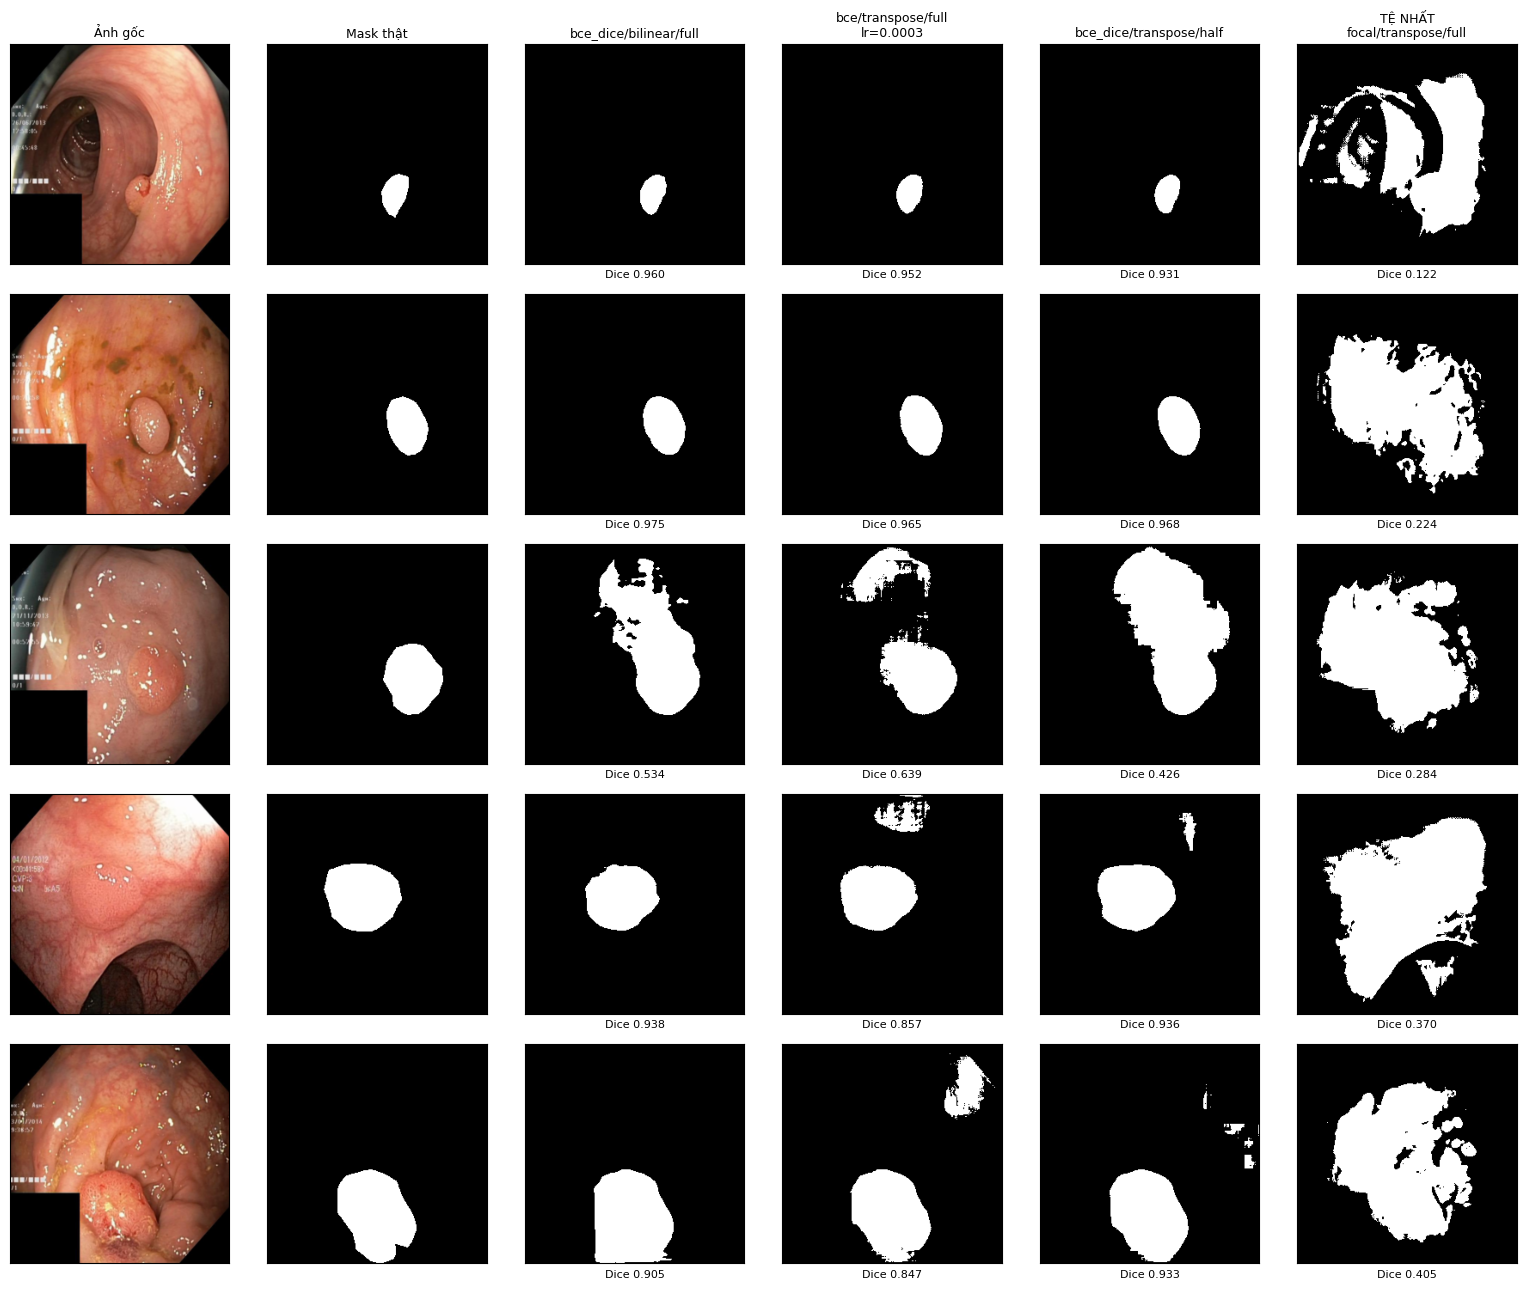

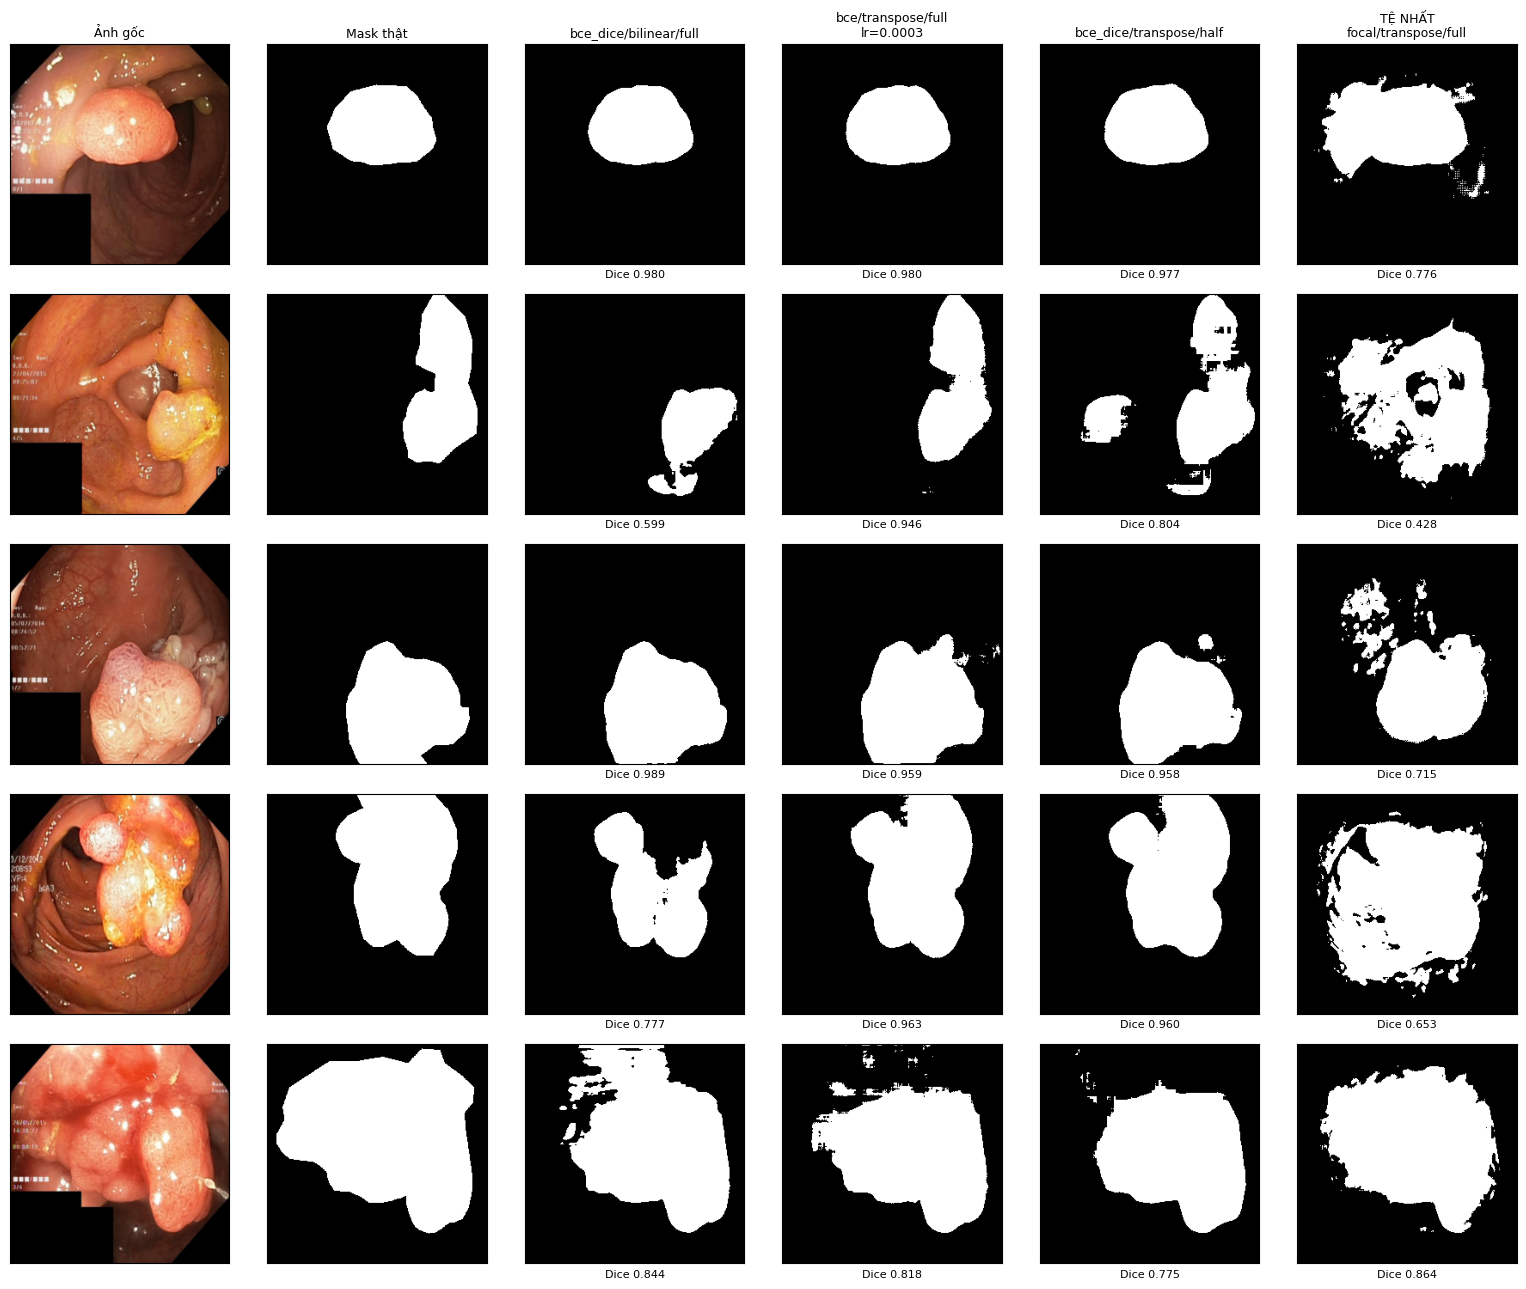

In [12]:
# Tách làm hai hình 5 hàng để vừa khổ giấy báo cáo
for k, half in enumerate([picks[:5], picks[5:]], start=1):
    comparison_grid(test_ds, models, indices=half, device=get_device(),
                    save_path=f"{cfg.fig_dir}/comparison_grid_{k}.png")

## Lưới ảnh gây bất đồng

Lưới trải đều kích thước ở trên minh hoạ phổ dữ liệu, nhưng phần lớn hàng cho
Dice trên 0.9 ở mọi cấu hình nên không phân biệt được gì. Lưới dưới chọn những
ảnh mà các cấu hình **bất đồng nhất** — đó mới là bằng chứng cho chênh lệch
trong bảng ablation.

In [13]:
import torch
from src.metrics import dice_per_image
from torch.utils.data import DataLoader

per_model = {}
for name, m in models.items():
    scores = []
    for images, masks in DataLoader(test_ds, batch_size=8, shuffle=False):
        with torch.no_grad():
            lg = m(images.to(get_device())).cpu()
        scores += dice_per_image(lg, masks).tolist()
    per_model[name] = np.array(scores)

mat = np.stack(list(per_model.values()))
spread = mat.std(axis=0)
contested = np.argsort(-spread)[:5].tolist()

print("5 ảnh gây bất đồng nhất (chỉ số, độ lệch chuẩn giữa các cấu hình):")
for i in contested:
    print(f"  {i:4d}  std={spread[i]:.3f}  " +
          "  ".join(f"{n.splitlines()[0]}={per_model[n][i]:.3f}" for n in per_model))

5 ảnh gây bất đồng nhất (chỉ số, độ lệch chuẩn giữa các cấu hình):
   135  std=0.395  bce_dice/bilinear/full=0.899  bce/transpose/full=0.921  bce_dice/transpose/half=0.938  TỆ NHẤT=0.009
    92  std=0.382  bce_dice/bilinear/full=0.939  bce/transpose/full=0.951  bce_dice/transpose/half=0.788  TỆ NHẤT=0.023
    51  std=0.376  bce_dice/bilinear/full=0.958  bce/transpose/full=0.949  bce_dice/transpose/half=0.959  TỆ NHẤT=0.087
    66  std=0.372  bce_dice/bilinear/full=0.960  bce/transpose/full=0.958  bce_dice/transpose/half=0.966  TỆ NHẤT=0.103
    31  std=0.365  bce_dice/bilinear/full=0.954  bce/transpose/full=0.941  bce_dice/transpose/half=0.942  TỆ NHẤT=0.103


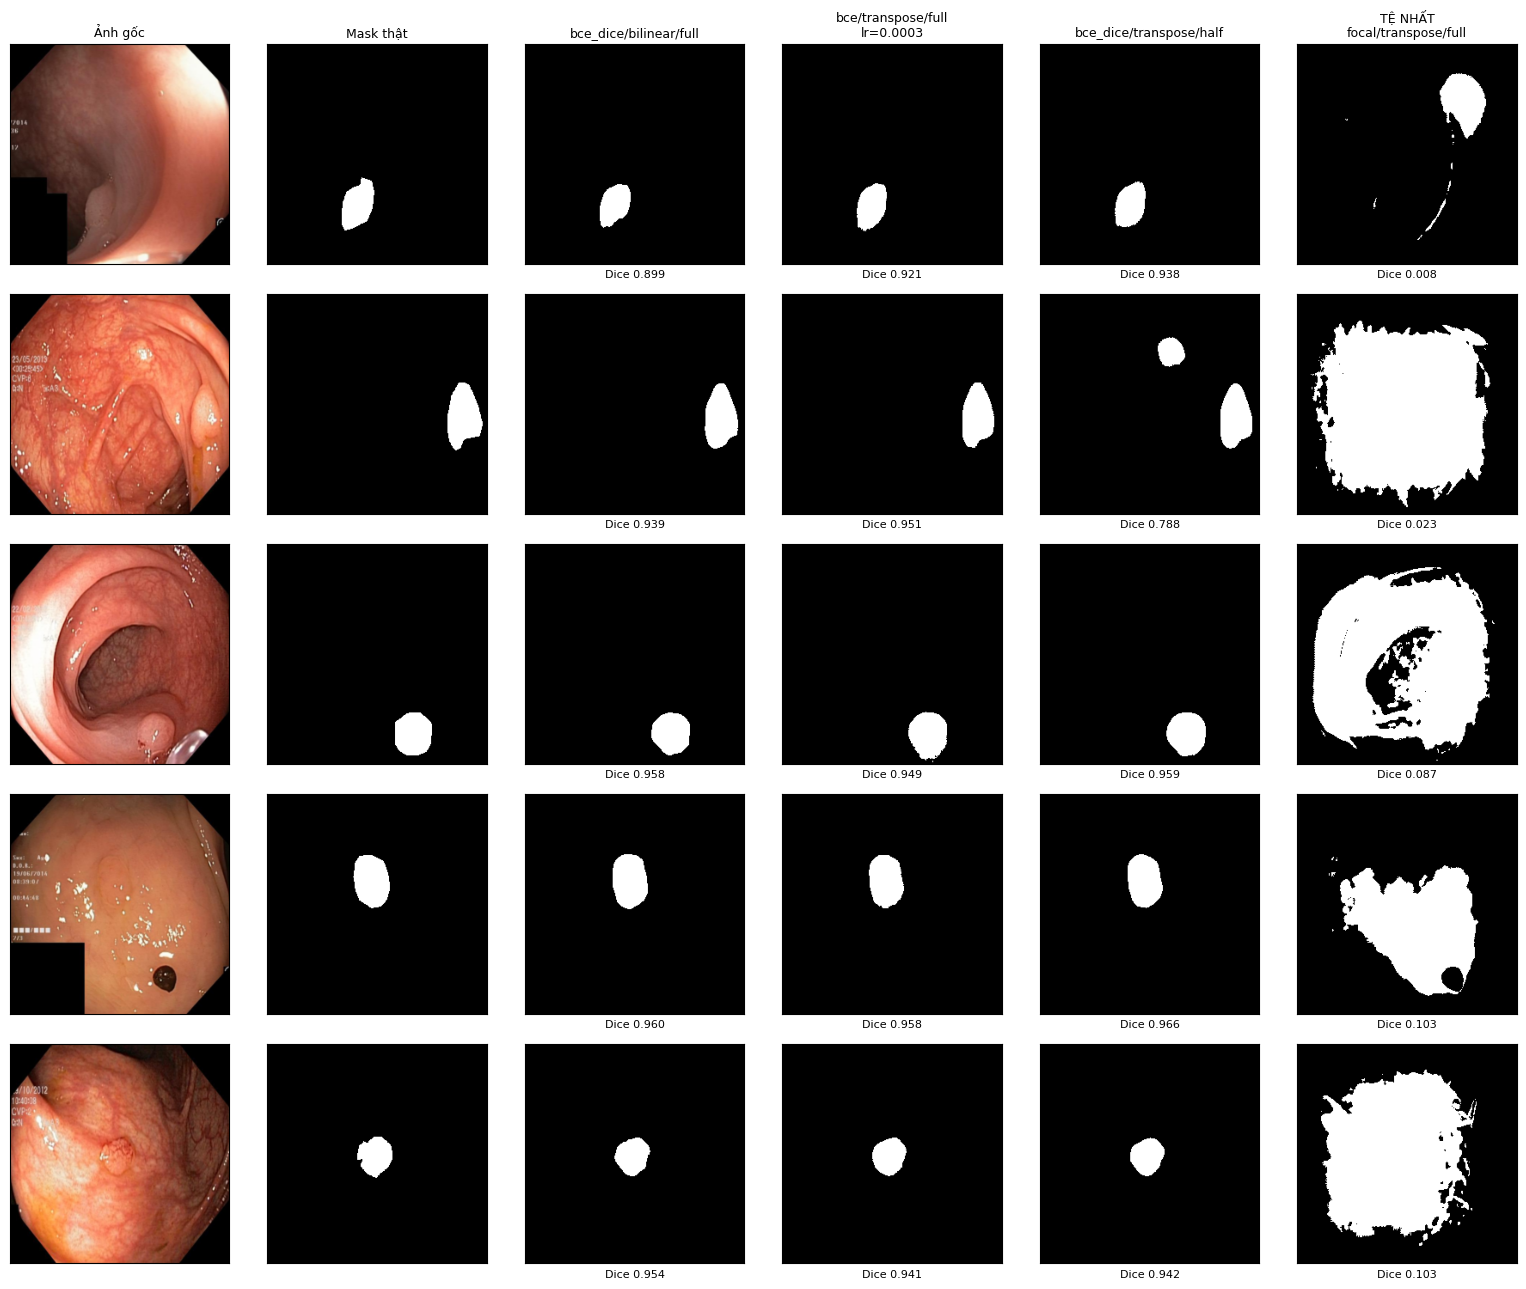

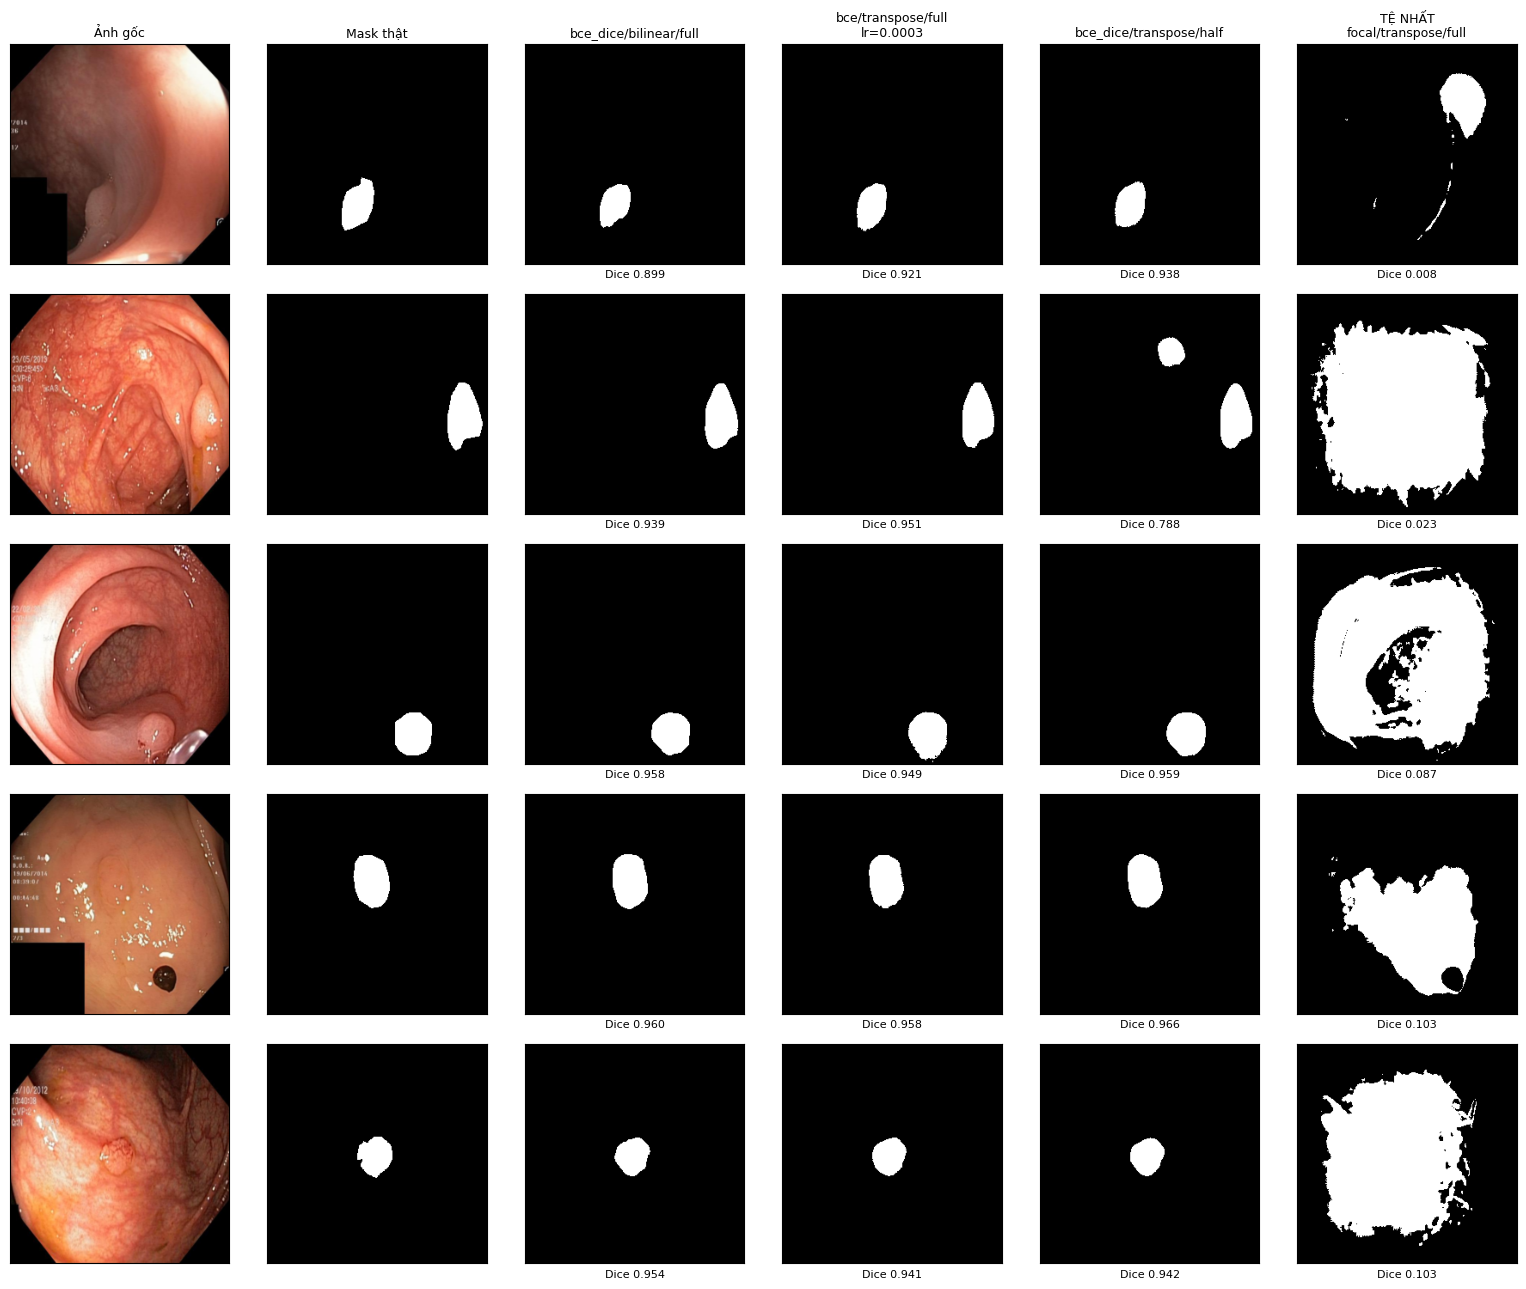

In [14]:
comparison_grid(test_ds, models, indices=contested, device=get_device(),
                save_path=f"{cfg.fig_dir}/comparison_contested.png")

### Dice trung bình theo kích thước polyp

Bảng này trả lời câu hỏi quan trọng nhất của phần phân tích lỗi: mỗi cấu hình
mạnh yếu ở loại polyp nào. Đây là chỗ sự đánh đổi của `skip_mode` lộ ra.

In [15]:
bins = pd.cut(areas, [0, .05, .15, .35, 1.0],
              labels=["rất nhỏ", "nhỏ", "vừa", "lớn"])
tbl = pd.DataFrame({n: s for n, s in per_model.items()})
tbl.columns = [c.splitlines()[0] for c in tbl.columns]
tbl["nhóm"] = bins
out = tbl.groupby("nhóm", observed=False).agg(["mean", "count"]).round(4)
print(out.to_markdown())

| nhóm    |   ('bce_dice/bilinear/full', 'mean') |   ('bce_dice/bilinear/full', 'count') |   ('bce/transpose/full', 'mean') |   ('bce/transpose/full', 'count') |   ('bce_dice/transpose/half', 'mean') |   ('bce_dice/transpose/half', 'count') |   ('TỆ NHẤT', 'mean') |   ('TỆ NHẤT', 'count') |
|:--------|-------------------------------------:|--------------------------------------:|---------------------------------:|----------------------------------:|--------------------------------------:|---------------------------------------:|----------------------:|-----------------------:|
| rất nhỏ |                               0.8598 |                                    23 |                           0.7964 |                                23 |                                0.7734 |                                     23 |                0.1696 |                     23 |
| nhỏ     |                               0.8626 |                                    62 |                           0.8441 

## Ảnh mô hình làm tệ nhất

Nguyên liệu cho mục *Phân tích và thảo luận*. Nhìn kỹ xem chúng có điểm chung
gì: polyp quá nhỏ, biên mờ, có bọt khí, ánh sáng chói, hay nhiều polyp.

Chỉ số 6 ảnh tệ nhất: [65, 68, 14, 46, 130, 4]


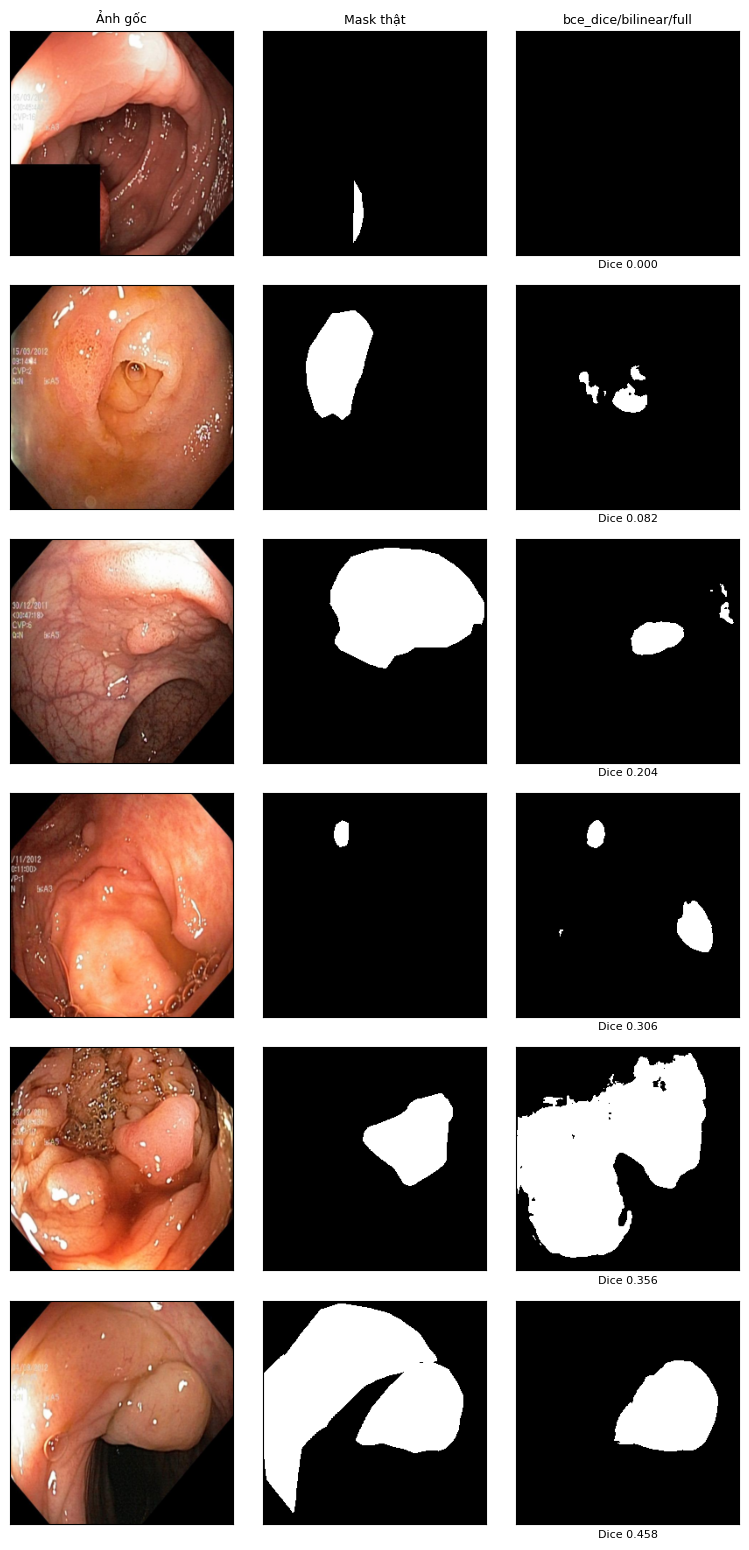

In [16]:
from src.viz import worst_case_indices
from torch.utils.data import DataLoader

best_name = list(models)[0]
loader = DataLoader(test_ds, batch_size=8, shuffle=False)
worst = worst_case_indices(models[best_name], loader, get_device(), k=6)
print("Chỉ số 6 ảnh tệ nhất:", worst)

fig = comparison_grid(test_ds, {best_name: models[best_name]}, indices=worst,
                      device=get_device(),
                      save_path=f"{cfg.fig_dir}/worst_cases.png")

## Danh sách kiểm trước khi nộp

- [ ] `logs/runs.csv` có đủ mọi lượt chạy, kể cả lượt hỏng
- [ ] Mọi số trong báo cáo đều đọc từ CSV, không gõ tay
- [ ] `README.md` chạy lại được từ đầu trên máy sạch
- [ ] `requirements.txt` khớp với môi trường thật
- [ ] Bảng phân công có tỉ lệ đóng góp cộng lại đúng 100%
- [ ] Mục *Khai báo sử dụng công cụ AI* ở cuối báo cáo
- [ ] Hình nào cũng có chú thích và được nhắc tới trong nội dung
- [ ] Mọi bảng đều ghi rõ `epochs` và `lr`, không trộn lẫn các ngân sách
- [ ] Cấu hình "tệ nhất" trong lưới ảnh là ablation có chủ đích, không phải lượt hỏng
- [ ] Có ít nhất một cấu hình chạy 2 seed để phát biểu về ý nghĩa thống kê